In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [17]:
test_predictions = pd.read_parquet("../data/test_predictions.parquet")
print(f"{len(test_predictions)} test-set predictions loaded")
test_predictions.head()

7442 test-set predictions loaded


,ListingKey,CloseDate,ClosePrice,PredictedClosePrice
0,1171562218,2026-05-28,"1,625,000.0000","1,437,726.1271"
1,1171541127,2026-05-15,"1,560,000.0000","1,672,926.6363"
2,1171287279,2026-05-29,"377,500.0000","364,647.8348"
3,1171065918,2026-05-29,"595,000.0000","855,407.2769"
4,1170805462,2026-05-29,"1,890,000.0000","2,508,647.6537"


## 3. Metrics Beyond R-Squared: MAPE and MdAPE

**MAPE** (Mean Absolute Percentage Error) - means are sensitive to outliers

**MdAPE** (Median Absolute Percentage Error) - medians are more robust to outliers and can better display the typical error

In [18]:
def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    ape = np.abs((y_true - y_pred) / y_true)
    return {
        "n": len(y_true),
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "mape": ape.mean(),
        "mdape": np.median(ape),
    }

overall_metrics = compute_metrics(test_predictions["ClosePrice"], test_predictions["PredictedClosePrice"])
overall_df = pd.DataFrame([{"segment": "Overall", **overall_metrics}])

skew_ratio = overall_metrics["mape"] / overall_metrics["mdape"]
print(f"Overall  R2={overall_metrics['r2']:.4f}  MAPE={overall_metrics['mape']:.4f}  MdAPE={overall_metrics['mdape']:.4f}")
print(f"MAPE / MdAPE ratio: {skew_ratio:.2f}")
if skew_ratio > 1.3:
    print("MAPE is notably higher than MdAPE -- a right-skewed error distribution, meaning a")
    print("subset of predictions with large percentage errors is pulling the mean up. MdAPE is")
    print("the more representative 'typical' error for most properties.")
else:
    print("MAPE and MdAPE are close -- errors are fairly evenly spread, without a small number")
    print("of outliers dominating the mean.")

overall_df

Overall  R2=0.9145  MAPE=0.1010  MdAPE=0.0689
MAPE / MdAPE ratio: 1.47
MAPE is notably higher than MdAPE -- a right-skewed error distribution, meaning a
subset of predictions with large percentage errors is pulling the mean up. MdAPE is
the more representative 'typical' error for most properties.


,segment,n,r2,mae,rmse,mape,mdape
0,Overall,7442,0.9145,"119,751.5207","230,495.8421",0.1010,0.0689


## 4. Price-Band Analysis

In [19]:
N_BANDS = 5
test_predictions["PriceBand"] = pd.qcut(test_predictions["ClosePrice"], q=N_BANDS)
band_labels = {b: f"${b.left:,.0f}–${b.right:,.0f}" for b in test_predictions["PriceBand"].cat.categories}
test_predictions["PriceBandLabel"] = test_predictions["PriceBand"].map(band_labels)

band_rows = []
for label, group in test_predictions.groupby("PriceBandLabel", observed=True):
    interval = group["PriceBand"].iloc[0]
    metrics = compute_metrics(group["ClosePrice"], group["PredictedClosePrice"])
    metrics["band_width"] = interval.right - interval.left
    band_rows.append({"segment": label, **metrics})
band_df = pd.DataFrame(band_rows)
band_df

,segment,n,r2,mae,rmse,mape,mdape,band_width
0,"$235,000–$550,000",1517,0.1086,"46,452.5537","73,276.9957",0.1126,0.0705,"315,000.0010"
1,"$550,000–$750,000",1488,-1.0169,"53,262.9292","80,735.8958",0.0818,0.0537,"200,000.0000"
2,"$750,000–$985,000",1464,-1.5650,"71,482.9824","106,394.4990",0.0828,0.0584,"235,000.0000"
3,"$985,000–$1,455,000",1489,-0.6910,"123,172.2339","174,715.0354",0.1022,0.0749,"470,000.0000"
4,"$1,455,000–$6,175,000",1484,0.7537,"305,534.0375","461,095.5259",0.1253,0.0955,"4,720,000.0000"


In [20]:
band_df["mae_to_width_ratio"] = band_df["mae"] / band_df["band_width"]
band_df[["segment", "band_width", "mae", "mae_to_width_ratio", "r2", "mape", "mdape"]].sort_values("r2")

,segment,band_width,mae,mae_to_width_ratio,r2,mape,mdape
2,"$750,000–$985,000","235,000.0000","71,482.9824",0.3042,-1.5650,0.0828,0.0584
1,"$550,000–$750,000","200,000.0000","53,262.9292",0.2663,-1.0169,0.0818,0.0537
3,"$985,000–$1,455,000","470,000.0000","123,172.2339",0.2621,-0.6910,0.1022,0.0749
0,"$235,000–$550,000","315,000.0010","46,452.5537",0.1475,0.1086,0.1126,0.0705
4,"$1,455,000–$6,175,000","4,720,000.0000","305,534.0375",0.0647,0.7537,0.1253,0.0955


In [26]:
best_band = band_df.loc[band_df["mdape"].idxmin()]
worst_band = band_df.loc[band_df["mdape"].idxmax()]
print(f"Best-performing price band (by mdape):  {best_band['segment']}  (R2={best_band['r2']:.4f}, MAPE={best_band['mape']:.4f}, MdAPE={best_band['mdape']:.4f})")
print(f"Worst-performing price band (by mdape): {worst_band['segment']}  (R2={worst_band['r2']:.4f}, MAPE={worst_band['mape']:.4f}, MdAPE={worst_band['mdape']:.4f})")

Best-performing price band (by mdape):  $550,000–$750,000  (R2=-1.0169, MAPE=0.0818, MdAPE=0.0537)
Worst-performing price band (by mdape): $1,455,000–$6,175,000  (R2=0.7537, MAPE=0.1253, MdAPE=0.0955)


### Visualizing MAPE vs. MdAPE by price band

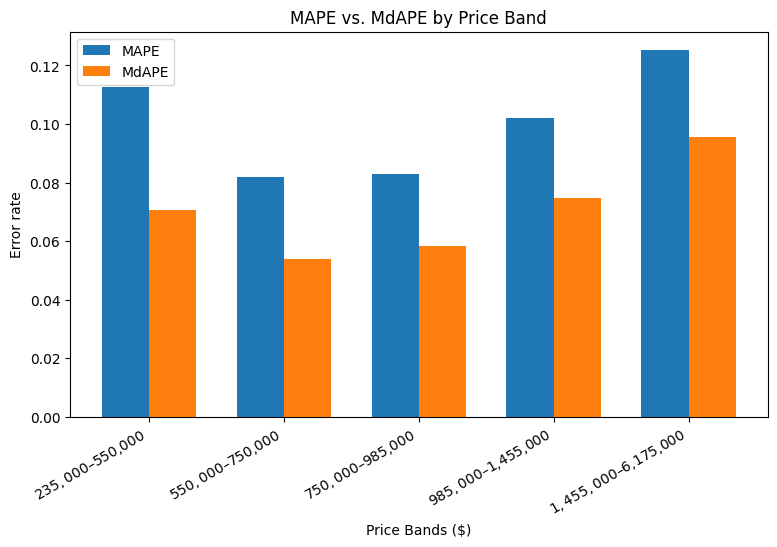

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(band_df))
width = 0.35

ax.bar(x - width/2, band_df["mape"], width, label="MAPE")
ax.bar(x + width/2, band_df["mdape"], width, label="MdAPE")
ax.set_xticks(x)
ax.set_xticklabels(band_df["segment"], rotation=30, ha="right")
ax.set_ylabel("Error rate")
ax.set_xlabel("Price Bands ($)")
ax.set_title("MAPE vs. MdAPE by Price Band")
ax.legend()

## 6. Export metrics_summary.csv

In [23]:
metrics_summary = pd.concat([overall_df, band_df], ignore_index=True)
metrics_summary.to_csv("../data/metrics_summary.csv", index=False)
print(f"Saved metrics_summary.csv ({len(metrics_summary)} rows: 1 overall + {len(band_df)} price bands)")
metrics_summary

Saved metrics_summary.csv (6 rows: 1 overall + 5 price bands)


,segment,n,r2,mae,rmse,mape,mdape,band_width,mae_to_width_ratio
0,Overall,7442,0.9145,"119,751.5207","230,495.8421",0.1010,0.0689,NaN,NaN
1,"$235,000–$550,000",1517,0.1086,"46,452.5537","73,276.9957",0.1126,0.0705,"315,000.0010",0.1475
2,"$550,000–$750,000",1488,-1.0169,"53,262.9292","80,735.8958",0.0818,0.0537,"200,000.0000",0.2663
3,"$750,000–$985,000",1464,-1.5650,"71,482.9824","106,394.4990",0.0828,0.0584,"235,000.0000",0.3042
4,"$985,000–$1,455,000",1489,-0.6910,"123,172.2339","174,715.0354",0.1022,0.0749,"470,000.0000",0.2621
5,"$1,455,000–$6,175,000",1484,0.7537,"305,534.0375","461,095.5259",0.1253,0.0955,"4,720,000.0000",0.0647
